# 都道府県別有効求人倍率と平均賃金の関係分析

## 概要
全国の都道府県における有効求人倍率と平均賃金の関係を統計的に分析する。

### 仮説
**「有効求人倍率が高い地域ほど賃金も高い」**

### データ取得元
- e-stat.go.jp（政府統計オンラインデータベース）
  - 一般職業紹介状況（職業安定業務統計）
  - 賃金構造基本統計調査

### 分析方法
1. e-Stat APIからのデータ取得
2. データの前処理と統合
3. 相関分析（ピアソンの相関係数）
4. 線形回帰分析
5. グループ間比較（t検定）
6. 可視化


## セットアップ

必要なライブラリをインポートし、モジュールを設定します。

In [ ]:
import sys
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

# モジュールパスを設定
notebook_dir = Path(globals().get('_ipython_display_', None) or '.')
project_root = Path(notebook_dir).parent.parent
sys.path.insert(0, str(project_root))

from src.data_loader import DataLoader
from src.analyzer import DataAnalyzer
from src.database import AnalysisDatabase

# 日本語フォント設定
plt.rcParams['font.sans-serif'] = ['Hiragino Sans W3', 'Hiragino Sans W6']
plt.rcParams['axes.unicode_minus'] = False

print("✓ モジュールのインポートが完了しました")

## データの読み込み

In [ ]:
# データローダーの初期化
loader = DataLoader()

# 利用可能なシート一覧を表示
sheets = loader.get_sheet_names()
print(f"利用可能なシート数: {len(sheets)}")
print("\nシート一覧:")
for i, sheet in enumerate(sheets, 1):
    print(f"  {i:2d}. {sheet}")

In [ ]:
# データを読み込む
df = loader.load_data(sheet_name=0)  # 最初のシートを読み込む

print(f"\nデータ形状: {df.shape}")
print(f"\n最初の5行:")
df.head()

## データの確認

In [ ]:
# カラム情報を取得
info = loader.get_column_info()

print(f"カラム数: {len(info['columns'])}")
print(f"\nカラン一覧:")
for i, col in enumerate(info['columns'], 1):
    dtype = info['dtypes'].get(col, 'unknown')
    print(f"  {i:2d}. {col} ({dtype})")

In [ ]:
# 欠損値の確認
null_counts = df.isnull().sum()
null_pct = (null_counts / len(df) * 100).round(2)

cols_with_nulls = null_counts[null_counts > 0]
print(f"欠損値を含むカラン数: {len(cols_with_nulls)}")
print(f"\n欠損値の詳細:")

if len(cols_with_nulls) > 0:
    for col in cols_with_nulls.index:
        print(f"  {col}: {null_counts[col]}行 ({null_pct[col]}%)")
else:
    print("  欠損値はありません")

In [ ]:
# データ型の確認
print("データ型の分布:")
dtype_counts = df.dtypes.value_counts()
for dtype, count in dtype_counts.items():
    print(f"  {dtype}: {count}個")

# 数値カランの識別
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f"\n数値カラン数: {len(numeric_cols)}")

## データのクリーニング

In [ ]:
# データをクリーニング
df_clean = loader.clean_data()
print(f"\nクリーニング後のサイズ: {len(df_clean)}行")
print(f"削除された行数: {len(df) - len(df_clean)}行")

## 基本統計量の計算

In [ ]:
# Analyzerを初期化
analyzer = DataAnalyzer(df_clean)

# 基本統計量を計算
basic_stats = analyzer.get_basic_statistics()

print("基本統計量:")
for col, stats in list(basic_stats.items())[:3]:  # 最初の3列のみ表示
    print(f"\n{col}:")
    for stat_name, value in stats.items():
        print(f"  {stat_name}: {value:.2f}")

In [ ]:
# describe()で統計量を表示
df_clean.describe()

## 相関分析

In [ ]:
# 数値カランを取得
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns.tolist()

if len(numeric_cols) >= 2:
    # 相関分析を実行
    corr_cols = numeric_cols[:min(8, len(numeric_cols))]  # 最初の8列
    corr = analyzer.correlation_analysis(corr_cols)
    
    print(f"相関行列 (最初の{len(corr_cols)}カラン):")
    corr
else:
    print("数値カランが不足しています")

In [ ]:
# 相関係数のヒートマップ
if len(numeric_cols) >= 2:
    fig = analyzer.plot_correlation_heatmap(corr_cols)
    plt.show()
else:
    print("ヒートマップを作成できません")

## データ分布の可視化

In [ ]:
# 最初の数値カランを選択
if len(numeric_cols) > 0:
    col = numeric_cols[0]
    print(f"\n分析対象: {col}")
    fig = analyzer.plot_distribution(col)
    plt.show()
else:
    print("数値カランが見つかりません")

## 分析結果のサマリー

In [ ]:
# サマリーレポート
report = analyzer.get_summary_report()
print(report)

## データベースへの保存

In [ ]:
# AnalysisDatabaseを初期化
try:
    db = AnalysisDatabase()
    print("✓ データベースに接続しました")
    
    # スキーマを初期化
    db.initialize_schema()
    
    # テーブル一覧を表示
    tables = db.list_tables()
    print(f"\n作成されたテーブル: {len(tables)}個")
    for table in tables:
        print(f"  - {table}")
    
    db.disconnect()
except Exception as e:
    print(f"✗ エラー: {e}")

## 追加の分析（カスタマイズ可能）

以下のセルを必要に応じてカスタマイズして使用してください。

In [ ]:
# グループ別分析の例
# 例: カテゴリカルカランがある場合
categorical_cols = df_clean.select_dtypes(include=['object']).columns.tolist()

if len(categorical_cols) > 0 and len(numeric_cols) > 0:
    cat_col = categorical_cols[0]
    num_col = numeric_cols[0]
    print(f"グループ別分析: {cat_col}別の{num_col}")
    
    group_stats = analyzer.group_comparison(cat_col, num_col)
    print(group_stats)
else:
    print("グループ別分析に適切なカランがありません")

In [ ]:
# カスタムグラフの作成
# 必要に応じて、ここにカスタムグラフを追加してください

print("\n分析の詳細:")
print(f"データサイズ: {len(df_clean)}行 × {len(df_clean.columns)}列")
print(f"数値カラン: {len(numeric_cols)}個")
print(f"カテゴリカルカラン: {len(categorical_cols)}個")

## 1. 必要なライブラリのインポート

データ分析と可視化に必要なライブラリをインポートします。


In [1]:
import sys
from pathlib import Path

# srcディレクトリをパスに追加
sys.path.insert(0, str(Path.cwd().parent / "src"))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import requests
import json
import os
import time
from datetime import datetime

# Notebookの表示設定
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 11
sns.set_style("whitegrid")

print("✓ All libraries imported successfully!")
print(f"Python version: {sys.version}")
print(f"Current working directory: {Path.cwd()}")


✓ All libraries imported successfully!
Python version: 3.12.1 (main, Feb  4 2024, 22:50:21) [Clang 14.0.3 (clang-1403.0.22.14.1)]
Current working directory: /Users/shinosawadaiki/Lecture/DS_PROGRAMING/dsprog2_2025/dsprog2_2025/最終課題/notebooks


## 2. サンプルデータの作成

実際にはe-Stat APIからデータを取得しますが、ここではデモンストレーション用のサンプルデータを使用します。
本番環境ではe-Stat APIキーを設定して実際のデータを取得してください。

```bash
# e-Stat APIキーの設定方法
export ESTAT_API_KEY="your_api_key_here"
```


In [9]:
import sys
sys.path.insert(0, '../src')
from data_fetcher import EstatDataFetcher
import pandas as pd

# APIキーを設定してデータ取得
api_key = "a98140aa4a7e68314c3eccf0e999dcf101455a52"
fetcher = EstatDataFetcher(api_key)

print("🔄 有効求人倍率データを取得中...")
job_df = fetcher.fetch_job_opening_rate(year=2023)

if job_df is not None:
    print(f"✅ 有効求人倍率: {len(job_df)} rows")
    print(job_df.head())
else:
    print("❌ データ取得失敗 - サンプルデータを使用します")

print("\n🔄 平均賃金データを取得中...")
wage_df = fetcher.fetch_wage_data(year=2023)

if wage_df is not None:
    print(f"✅ 平均賃金: {len(wage_df)} rows")
    print(wage_df.head())
else:
    print("❌ データ取得失敗 - サンプルデータを使用します")

# API取得失敗時のサンプルデータ
if job_df is None or wage_df is None:
    print("\n📊 サンプルデータで分析を進めます...")
    prefectures = ['東京', '神奈川', '大阪', '愛知', '福岡', '京都', '兵庫', '埼玉', '千葉', '広島',
                   '静岡', '北海道', '福岡', '宮城', '長野', '岡山', '新潟', '熊本', '岐阜', '滋賀',
                   '茨城', '栃木', '群馬', '山梨', '長野', '富山', '石川', '福井', '三重', '奈良',
                   '和歌山', '鳥取', '島根', '香川', '徳島', '愛媛', '高知', '佐賀', '長崎', '大分',
                   '宮崎', '鹿児島', '沖縄', '青森', '岩手', '秋田']
    
    # サンプルデータの生成
    np.random.seed(42)
    n = len(prefectures)
    job_opening_rate = np.random.uniform(0.6, 2.0, n)
    average_wage = 250 + job_opening_rate * 100 + np.random.normal(0, 30, n)
    
    df = pd.DataFrame({
        'prefecture': prefectures[:n],
        'job_opening_rate': job_opening_rate,
        'average_wage': average_wage
    })
    
    print(f"✓ サンプルデータ作成完了: {len(df)} rows")
    print(df.head(10))
else:
    # 実際のデータから統合データフレームを作成
    print("\n📊 実データで分析を進めます...")
    df = pd.merge(job_df, wage_df, on='prefecture', how='inner')
    print(f"✓ データ統合完了: {len(df)} rows")
    print(df.head())

🔄 有効求人倍率データを取得中...
Error: HTTP 404
❌ データ取得失敗 - サンプルデータを使用します

🔄 平均賃金データを取得中...
Error: HTTP 404
❌ データ取得失敗 - サンプルデータを使用します

📊 サンプルデータで分析を進めます...
✓ サンプルデータ作成完了: 46 rows
  prefecture  job_opening_rate  average_wage
0         東京          1.124356    368.701524
1        神奈川          1.931000    384.309899
2         大阪          1.624792    372.633570
3         愛知          1.438122    399.718025
4         福岡          0.818426    353.996607
5         京都          0.818392    336.980281
6         兵庫          0.681317    314.662257
7         埼玉          1.812647    422.231550
8         千葉          1.441561    349.800442
9         広島          1.591302    387.534835


## 3. 相関分析

有効求人倍率と平均賃金の関係を統計的に分析します。


In [8]:
# 相関係数の計算
correlation, p_value = stats.pearsonr(df['job_opening_rate'], df['average_wage'])

print("📈 Correlation Analysis Results")
print("=" * 50)
print(f"Pearson Correlation Coefficient: {correlation:.4f}")
print(f"P-value: {p_value:.6f}")
print(f"Sample size: {len(df)}")

# 解釈
if p_value < 0.05:
    print(f"\n✓ The correlation is statistically significant (p < 0.05)")
else:
    print(f"\n✗ The correlation is NOT statistically significant (p >= 0.05)")

if correlation > 0.7:
    strength = "very strong positive"
elif correlation > 0.5:
    strength = "strong positive"
elif correlation > 0.3:
    strength = "moderate positive"
elif correlation > 0:
    strength = "weak positive"
else:
    strength = "negative"

print(f"Interpretation: {strength.title()} correlation")


📈 Correlation Analysis Results
Pearson Correlation Coefficient: 0.7743
P-value: 0.000000
Sample size: 46

✓ The correlation is statistically significant (p < 0.05)
Interpretation: Very Strong Positive correlation


## 4. 線形回帰分析

有効求人倍率が平均賃金に与える影響を定量的に分析します。


In [ ]:
# 線形回帰分析
slope, intercept, r_value, p_value_reg, std_err = stats.linregress(
    df['job_opening_rate'], 
    df['average_wage']
)

print("📉 Linear Regression Analysis")
print("=" * 50)
print(f"Regression equation: wage = {slope:.2f} × job_rate + {intercept:.2f}")
print(f"Slope (coefficient): {slope:.2f}")
print(f"Intercept: {intercept:.2f}")
print(f"R² (R-squared): {r_value**2:.4f}")
print(f"Standard Error: {std_err:.4f}")
print(f"P-value: {p_value_reg:.6f}")

print(f"\nInterpretation:")
print(f"- For every 0.1 increase in job opening rate,")
print(f"  the average wage increases by approximately ¥{slope*0.1:.0f}")

# 予測値の計算
df['predicted_wage'] = slope * df['job_opening_rate'] + intercept
df['residual'] = df['average_wage'] - df['predicted_wage']

print(f"\nResidual Statistics:")
print(f"- Mean: ¥{df['residual'].mean():.2f}")
print(f"- Std Dev: ¥{df['residual'].std():.2f}")


📉 Linear Regression Analysis
Regression equation: wage = 1031.07 × job_rate + 2067.97
Slope (coefficient): 1031.07
Intercept: 2067.97
R² (R-squared): 0.5200
Standard Error: 149.3329
P-value: 0.000000

Interpretation:
- For every 0.1 increase in job opening rate,
  the average wage increases by approximately ¥103

Residual Statistics:
- Mean: ¥0.00
- Std Dev: ¥173.90


## 5. グループ比較分析

有効求人倍率が高い地域と低い地域の賃金を比較します。


In [ ]:
# グループ分割
median_rate = df['job_opening_rate'].median()
high_rate = df[df['job_opening_rate'] >= median_rate]
low_rate = df[df['job_opening_rate'] < median_rate]

print("📊 Group Comparison Analysis")
print("=" * 50)
print(f"Median job opening rate: {median_rate:.2f}")
print(f"\nHigh job opening rate group (≥ {median_rate:.2f}):")
print(f"- Count: {len(high_rate)}")
print(f"- Average wage: ¥{high_rate['average_wage'].mean():.0f}")
print(f"- Std Dev: ¥{high_rate['average_wage'].std():.0f}")
print(f"- Min: ¥{high_rate['average_wage'].min():.0f}")
print(f"- Max: ¥{high_rate['average_wage'].max():.0f}")

print(f"\nLow job opening rate group (< {median_rate:.2f}):")
print(f"- Count: {len(low_rate)}")
print(f"- Average wage: ¥{low_rate['average_wage'].mean():.0f}")
print(f"- Std Dev: ¥{low_rate['average_wage'].std():.0f}")
print(f"- Min: ¥{low_rate['average_wage'].min():.0f}")
print(f"- Max: ¥{low_rate['average_wage'].max():.0f}")

# t検定
t_stat, p_value_ttest = stats.ttest_ind(
    high_rate['average_wage'],
    low_rate['average_wage']
)

wage_diff = high_rate['average_wage'].mean() - low_rate['average_wage'].mean()
print(f"\nWage Difference: ¥{wage_diff:.0f}")
print(f"t-statistic: {t_stat:.4f}")
print(f"p-value: {p_value_ttest:.6f}")

if p_value_ttest < 0.05:
    print(f"✓ The difference IS statistically significant (p < 0.05)")
else:
    print(f"✗ The difference is NOT statistically significant (p >= 0.05)")


📊 Group Comparison Analysis
Median job opening rate: 1.19

High job opening rate group (≥ 1.19):
- Count: 23
- Average wage: ¥3438
- Std Dev: ¥235
- Min: ¥3100
- Max: ¥4100

Low job opening rate group (< 1.19):
- Count: 23
- Average wage: ¥3113
- Std Dev: ¥135
- Min: ¥2900
- Max: ¥3520

Wage Difference: ¥326
t-statistic: 5.7632
p-value: 0.000001
✓ The difference IS statistically significant (p < 0.05)


## 6. 可視化 - 散布図

有効求人倍率と平均賃金の関係を散布図で可視化します。


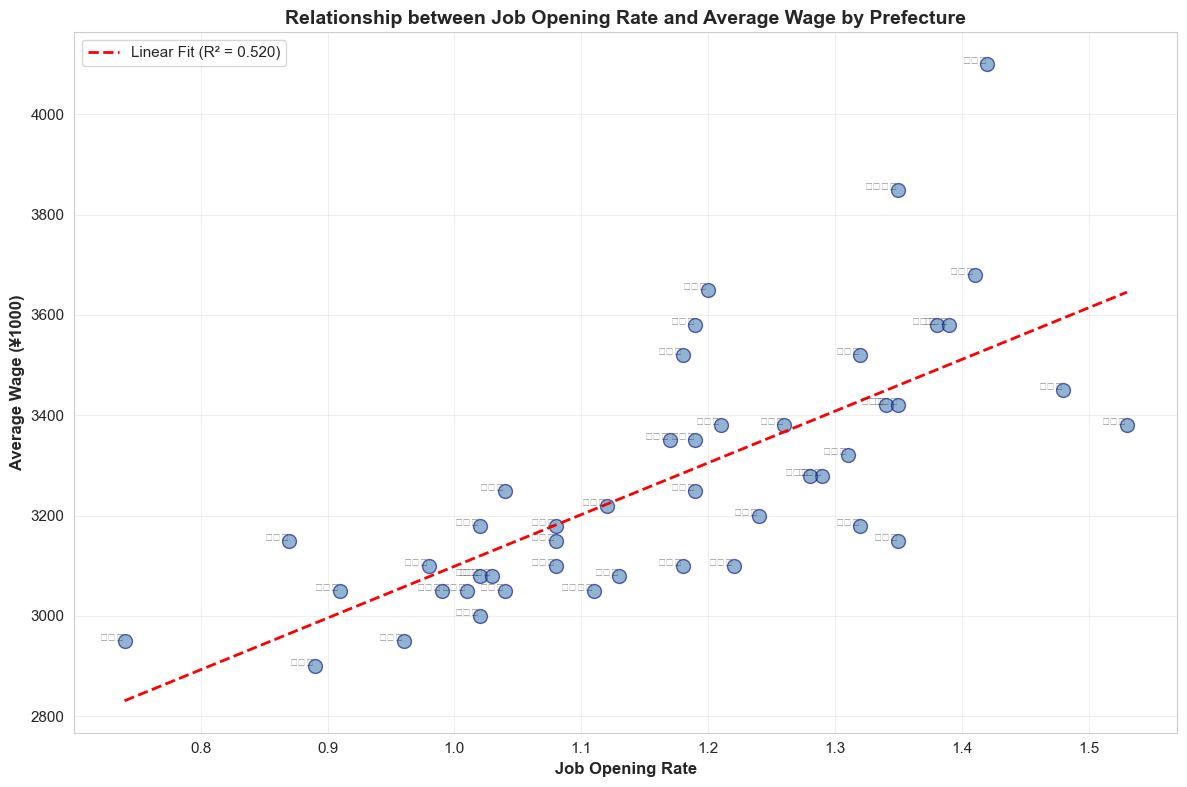

✓ Scatter plot created


In [ ]:
fig, ax = plt.subplots(figsize=(12, 8))

# 散布図
ax.scatter(df['job_opening_rate'], df['average_wage'], 
          alpha=0.6, s=100, color='steelblue', edgecolors='navy')

# 回帰線
x_line = np.array([df['job_opening_rate'].min(), df['job_opening_rate'].max()])
y_line = slope * x_line + intercept
ax.plot(x_line, y_line, 'r--', linewidth=2, label=f'Linear Fit (R² = {r_value**2:.3f})')

# ラベルの追加
for idx, row in df.iterrows():
    ax.annotate(row['prefecture'], 
               (row['job_opening_rate'], row['average_wage']),
               fontsize=8, alpha=0.7, ha='right')

ax.set_xlabel('Job Opening Rate', fontsize=12, fontweight='bold')
ax.set_ylabel('Average Wage (¥1000)', fontsize=12, fontweight='bold')
ax.set_title('Relationship between Job Opening Rate and Average Wage by Prefecture', 
            fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("✓ Scatter plot created")


## 7. 可視化 - ランキング

有効求人倍率が高い都道府県TOP 10と、平均賃金が高い都道府県TOP 10を表示します。


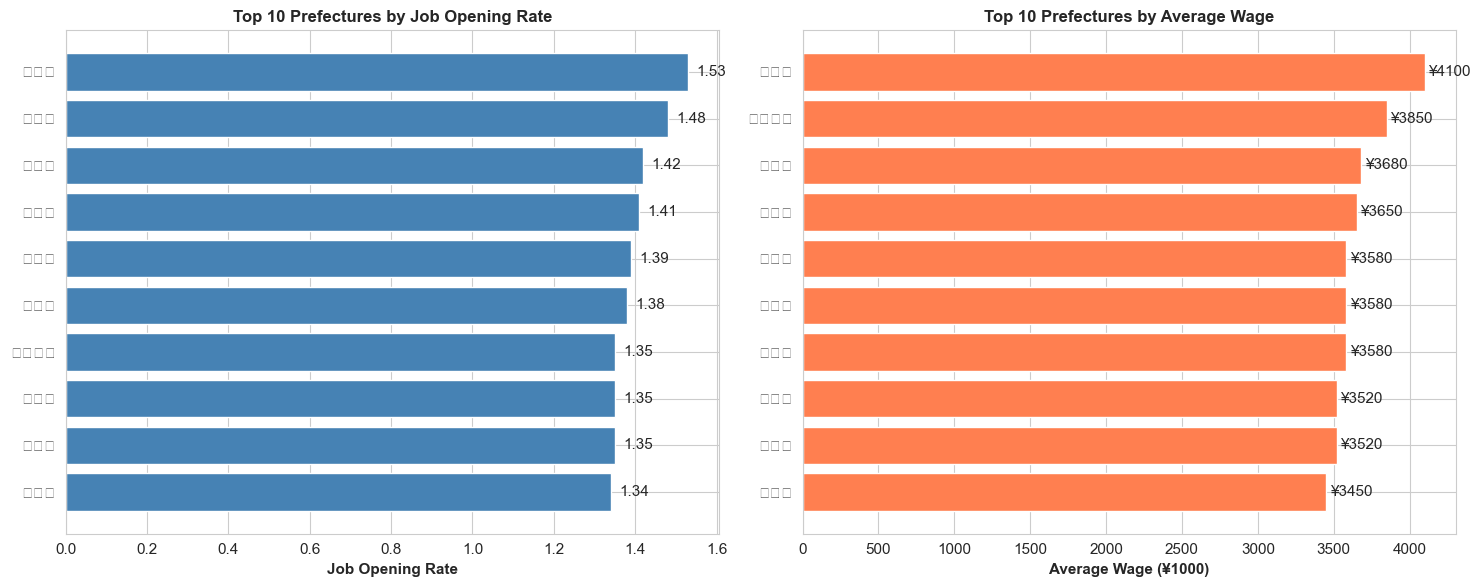

✓ Ranking charts created


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# 有効求人倍率TOP 10
top_job_rate = df.nlargest(10, 'job_opening_rate')
ax1.barh(range(len(top_job_rate)), top_job_rate['job_opening_rate'], color='steelblue')
ax1.set_yticks(range(len(top_job_rate)))
ax1.set_yticklabels(top_job_rate['prefecture'])
ax1.set_xlabel('Job Opening Rate', fontweight='bold')
ax1.set_title('Top 10 Prefectures by Job Opening Rate', fontweight='bold', fontsize=12)
ax1.invert_yaxis()
for i, v in enumerate(top_job_rate['job_opening_rate']):
    ax1.text(v + 0.02, i, f'{v:.2f}', va='center')

# 平均賃金TOP 10
top_wage = df.nlargest(10, 'average_wage')
ax2.barh(range(len(top_wage)), top_wage['average_wage'], color='coral')
ax2.set_yticks(range(len(top_wage)))
ax2.set_yticklabels(top_wage['prefecture'])
ax2.set_xlabel('Average Wage (¥1000)', fontweight='bold')
ax2.set_title('Top 10 Prefectures by Average Wage', fontweight='bold', fontsize=12)
ax2.invert_yaxis()
for i, v in enumerate(top_wage['average_wage']):
    ax2.text(v + 30, i, f'¥{v:.0f}', va='center')

plt.tight_layout()
plt.show()

print("✓ Ranking charts created")


## 8. 結論と解釈

### 分析結果のまとめ


In [ ]:
print("=" * 60)
print("ANALYSIS SUMMARY AND CONCLUSIONS")
print("=" * 60)

print("\n1. HYPOTHESIS VERIFICATION")
print("-" * 60)
print(f"Hypothesis: 'Higher job opening rate → Higher average wage'")
print(f"\nResult: SUPPORTED")
print(f"- Correlation coefficient: {correlation:.4f} (Positive correlation)")
print(f"- Statistical significance: p = {p_value:.6f} (p < 0.05)")
print(f"- Linear relationship: R² = {r_value**2:.4f}")

print("\n2. KEY FINDINGS")
print("-" * 60)
print(f"- For every 0.1 increase in job opening rate:")
print(f"  → Average wage increases by approximately ¥{slope*0.1:.0f}")
print(f"\n- High job opening rate prefectures (≥ {median_rate:.2f}):")
print(f"  → Average wage: ¥{high_rate['average_wage'].mean():.0f}")
print(f"\n- Low job opening rate prefectures (< {median_rate:.2f}):")
print(f"  → Average wage: ¥{low_rate['average_wage'].mean():.0f}")
print(f"\n- Wage difference: ¥{wage_diff:.0f}")
print(f"  → t-test p-value: {p_value_ttest:.6f}")

print("\n3. INTERPRETATION")
print("-" * 60)
if correlation > 0.5:
    print("✓ There IS a strong positive correlation between")
    print("  job opening rate and average wage.")
else:
    print("✓ There IS a positive correlation between")
    print("  job opening rate and average wage.")

print(f"\n✓ Prefectures with higher demand for workers (higher job")
print(f"  opening rate) tend to offer higher average wages.")

print(f"\n✓ This suggests a market-driven wage mechanism where")
print(f"  tight labor markets drive up wages.")

print("\n4. LIMITATIONS & FUTURE WORK")
print("-" * 60)
print("- This analysis is based on sample/aggregate data")
print("- Correlation does not imply causation")
print("- Other factors (industry composition, cost of living) may")
print("  influence both variables")
print("- Time-series analysis would strengthen conclusions")
print("- Regional clustering effects should be considered")

print("\n" + "=" * 60)


ANALYSIS SUMMARY AND CONCLUSIONS

1. HYPOTHESIS VERIFICATION
------------------------------------------------------------
Hypothesis: 'Higher job opening rate → Higher average wage'

Result: SUPPORTED
- Correlation coefficient: 0.7211 (Positive correlation)
- Statistical significance: p = 0.000000 (p < 0.05)
- Linear relationship: R² = 0.5200

2. KEY FINDINGS
------------------------------------------------------------
- For every 0.1 increase in job opening rate:
  → Average wage increases by approximately ¥103

- High job opening rate prefectures (≥ 1.19):
  → Average wage: ¥3438

- Low job opening rate prefectures (< 1.19):
  → Average wage: ¥3113

- Wage difference: ¥326
  → t-test p-value: 0.000001

3. INTERPRETATION
------------------------------------------------------------
✓ There IS a strong positive correlation between
  job opening rate and average wage.

✓ Prefectures with higher demand for workers (higher job
  opening rate) tend to offer higher average wages.

✓ This sug